# Lending Club: Screening Peer-Lending Loans for Better Outcomes
## Update 1 — Diagnostic and Descriptive Models

**45-952 End-to-End Business Analytics — Fall 2026**

This notebook is scoped to **Update 1** of the Lending Club case (*Screening
peer-lending loans for better outcomes*): business understanding, data
understanding, descriptive analysis, K-means clustering, and PCA. Predictive
modeling (logistic regression, decision trees) and prescriptive/optimization
work are out of scope here and are addressed in Updates 2 and 3.

Data: `data/loanskpi.csv` (9,578 three-year loans funded by Lending Club,
May 2007–Feb 2010), described in `docs/LoansDataDescr.pdf`. Business context:
`docs/MBA_CreditDefault_Case_Fall2026.pdf`.


## 1. Business Understanding

Lending Club's Executive Committee is weighing several related decisions:

- **Which loan applications to feature to investors** on the platform (the
  core screening decision).
- **How to price interest rates by risk tier** once an applicant is accepted.
- **Which borrower segments to prioritize** for growth outreach.

Three ExCo members care about different outcomes of these decisions:
- **CEO** — return on invested capital (ROIC) for platform investors.
- **CFO** — profit earned from interest (net of Lending Club's cut).
- **CMO** — market share growth against competitors (e.g., Prosper).

**Scope of this analysis:** we focus on the **screening decision** — which
loan applications should be featured to investors in the first place. A
model that reliably flags high-risk applications *before* they are shown to
investors directly serves all three ExCo members: it protects ROIC and
interest profit by avoiding defaults, and it protects market share by
keeping investor returns competitive (an investor base with better
risk-adjusted returns is Lending Club's best growth engine against
competitors like Prosper). Pricing (interest-rate-by-risk-tier) and
portfolio-level optimization build on this same risk model and are deferred
to Updates 2–3.


## 2. Source of Value

Lending Club's key asset is its **historical record of funded loans and
their outcomes** — the terms offered (rate, installment), the borrower's
credit-bureau profile at the time of application, and whether the loan was
ultimately paid back in full or defaulted/charged off.

The value-creation logic for this project:

1. **Learn** the statistical relationship between borrower/loan
   characteristics known *at the time of funding* and the eventual default
   outcome, using this historical sample.
2. **Screen** new applications through that learned relationship *before*
   they are ever shown to investors, flagging high-risk applications.
3. **Improve outcomes** for all three ExCo constituencies: fewer bad loans
   funded improves ROIC and interest profit, and a track record of solid
   investor returns is a durable market-share advantage.

Update 1 lays the groundwork for step 1 — understanding the data and its
structure — before Update 2 builds the actual predictive (classification)
models.


## 3. Data Understanding

### 3.1 Unit of analysis

Each row in `loanskpi.csv` is **one 3-year loan** funded through the
LendingClub.com platform between May 2007 and February 2010 (9,578 loans).

### 3.2 Feature groups and data dynamism

A critical distinction for modeling: which fields are known **at the time of
the funding decision** versus which are only **computed after the loan's
outcome is known**. Using the latter as predictors would leak the answer
into the model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


In [2]:
known_at_application = ['credit.policy', 'purpose', 'int.rate', 'installment',
                         'log.annual.inc', 'dti', 'fico', 'days.with.cr.line',
                         'revol.bal', 'revol.util', 'inq.last.6mths',
                         'delinq.2yrs', 'pub.rec']
target = ['default']
computed_after_outcome = ['tot.payment', 'principal', 'interest']

field_roles = pd.DataFrame({
    'field': known_at_application + target + computed_after_outcome,
    'role': (['Known at application'] * len(known_at_application)
             + ['Target (outcome)']
             + ['Computed after outcome (KPI, not a predictor)'] * len(computed_after_outcome))
})
display(field_roles)


,field,role
0,credit.policy,Known at application
1,purpose,Known at application
2,int.rate,Known at application
3,installment,Known at application
4,log.annual.inc,Known at application
5,dti,Known at application
6,fico,Known at application
7,days.with.cr.line,Known at application
8,revol.bal,Known at application
9,revol.util,Known at application


**Implication for modeling:** `tot.payment`, `principal`, and `interest`
are deterministic functions of `installment`/`int.rate` and the loan's
outcome — they must **never** be used as predictive features for a
funding-decision model (they are provided only to later compute profit,
loss, and ROIC once a screening decision has been made). All descriptive
analysis, clustering, and PCA below use only the 13 fields known at
application time (plus `default` as the outcome for cross-tabulation, never
as a clustering/PCA input).

### 3.3 Which features likely matter most for profitability?

Based on the data description and lending-industry intuition, the fields
most likely to drive eventual profitability are:

- **`fico`** — the borrower's credit score; the single most standard proxy
  for repayment risk.
- **`int.rate`** — already reflects LendingClub's own risk assessment, so it
  is both a feature and a partial "answer key" for risk. (As Section 4.3
  shows, it is also the single most correlated variable with `fico` in the
  application-time set — we revisit whether to include both in Section 5.1.)
- **`revol.util`** — how much of the available revolving credit is in use;
  a classic over-leverage signal.
- **`dti`** — debt-to-income ratio; captures repayment capacity relative to
  income.
- **`inq.last.6mths`** — recent credit inquiries, a signal of active
  credit-shopping / financial stress.
- **`purpose`** — the stated reason for borrowing (e.g., `small_business`
  loans are inherently riskier than `credit_card` refinancing).

We test these hypotheses empirically in the descriptive analysis below.

### 3.4 Structure, types, and missing values


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  default            9578 non-null   int64  
 14  tot.payment        9578 non-null   float64
 15  principal          9578 non-null   float64
 16  interest           9578 non-null   

In [4]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


In [5]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
missing['% Missing'] = (missing['Missing Values'] / len(df) * 100).round(2)
display(missing)
print(f"\nOverall default rate: {df['default'].mean()*100:.1f}%")


,Missing Values,% Missing
credit.policy,0,0.0
purpose,0,0.0
int.rate,0,0.0
installment,0,0.0
log.annual.inc,0,0.0
dti,0,0.0
fico,0,0.0
days.with.cr.line,0,0.0
revol.bal,0,0.0
revol.util,0,0.0



Overall default rate: 16.0%


## 4. Descriptive Analysis

### 4.1 Categorical variable distributions

`purpose` is the only text-categorical field; `credit.policy` is a binary
underwriting flag.


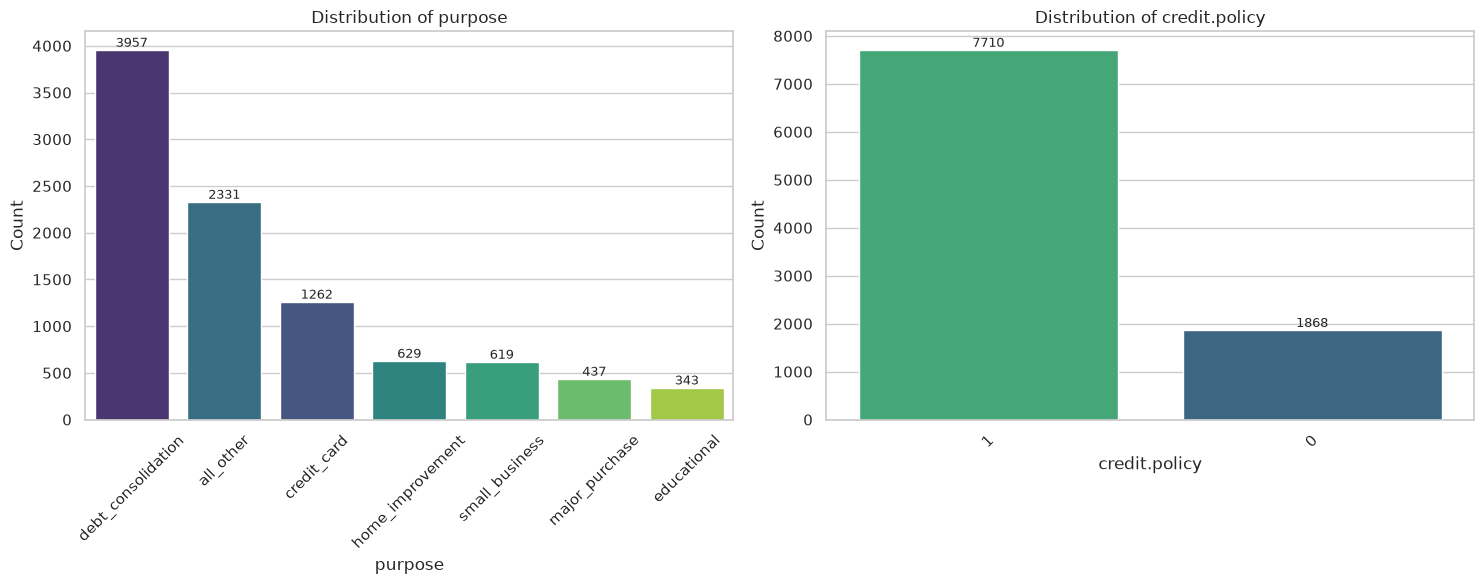

In [6]:
categorical_cols = ['purpose', 'credit.policy']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 6))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Numerical variable distributions (application-time fields)

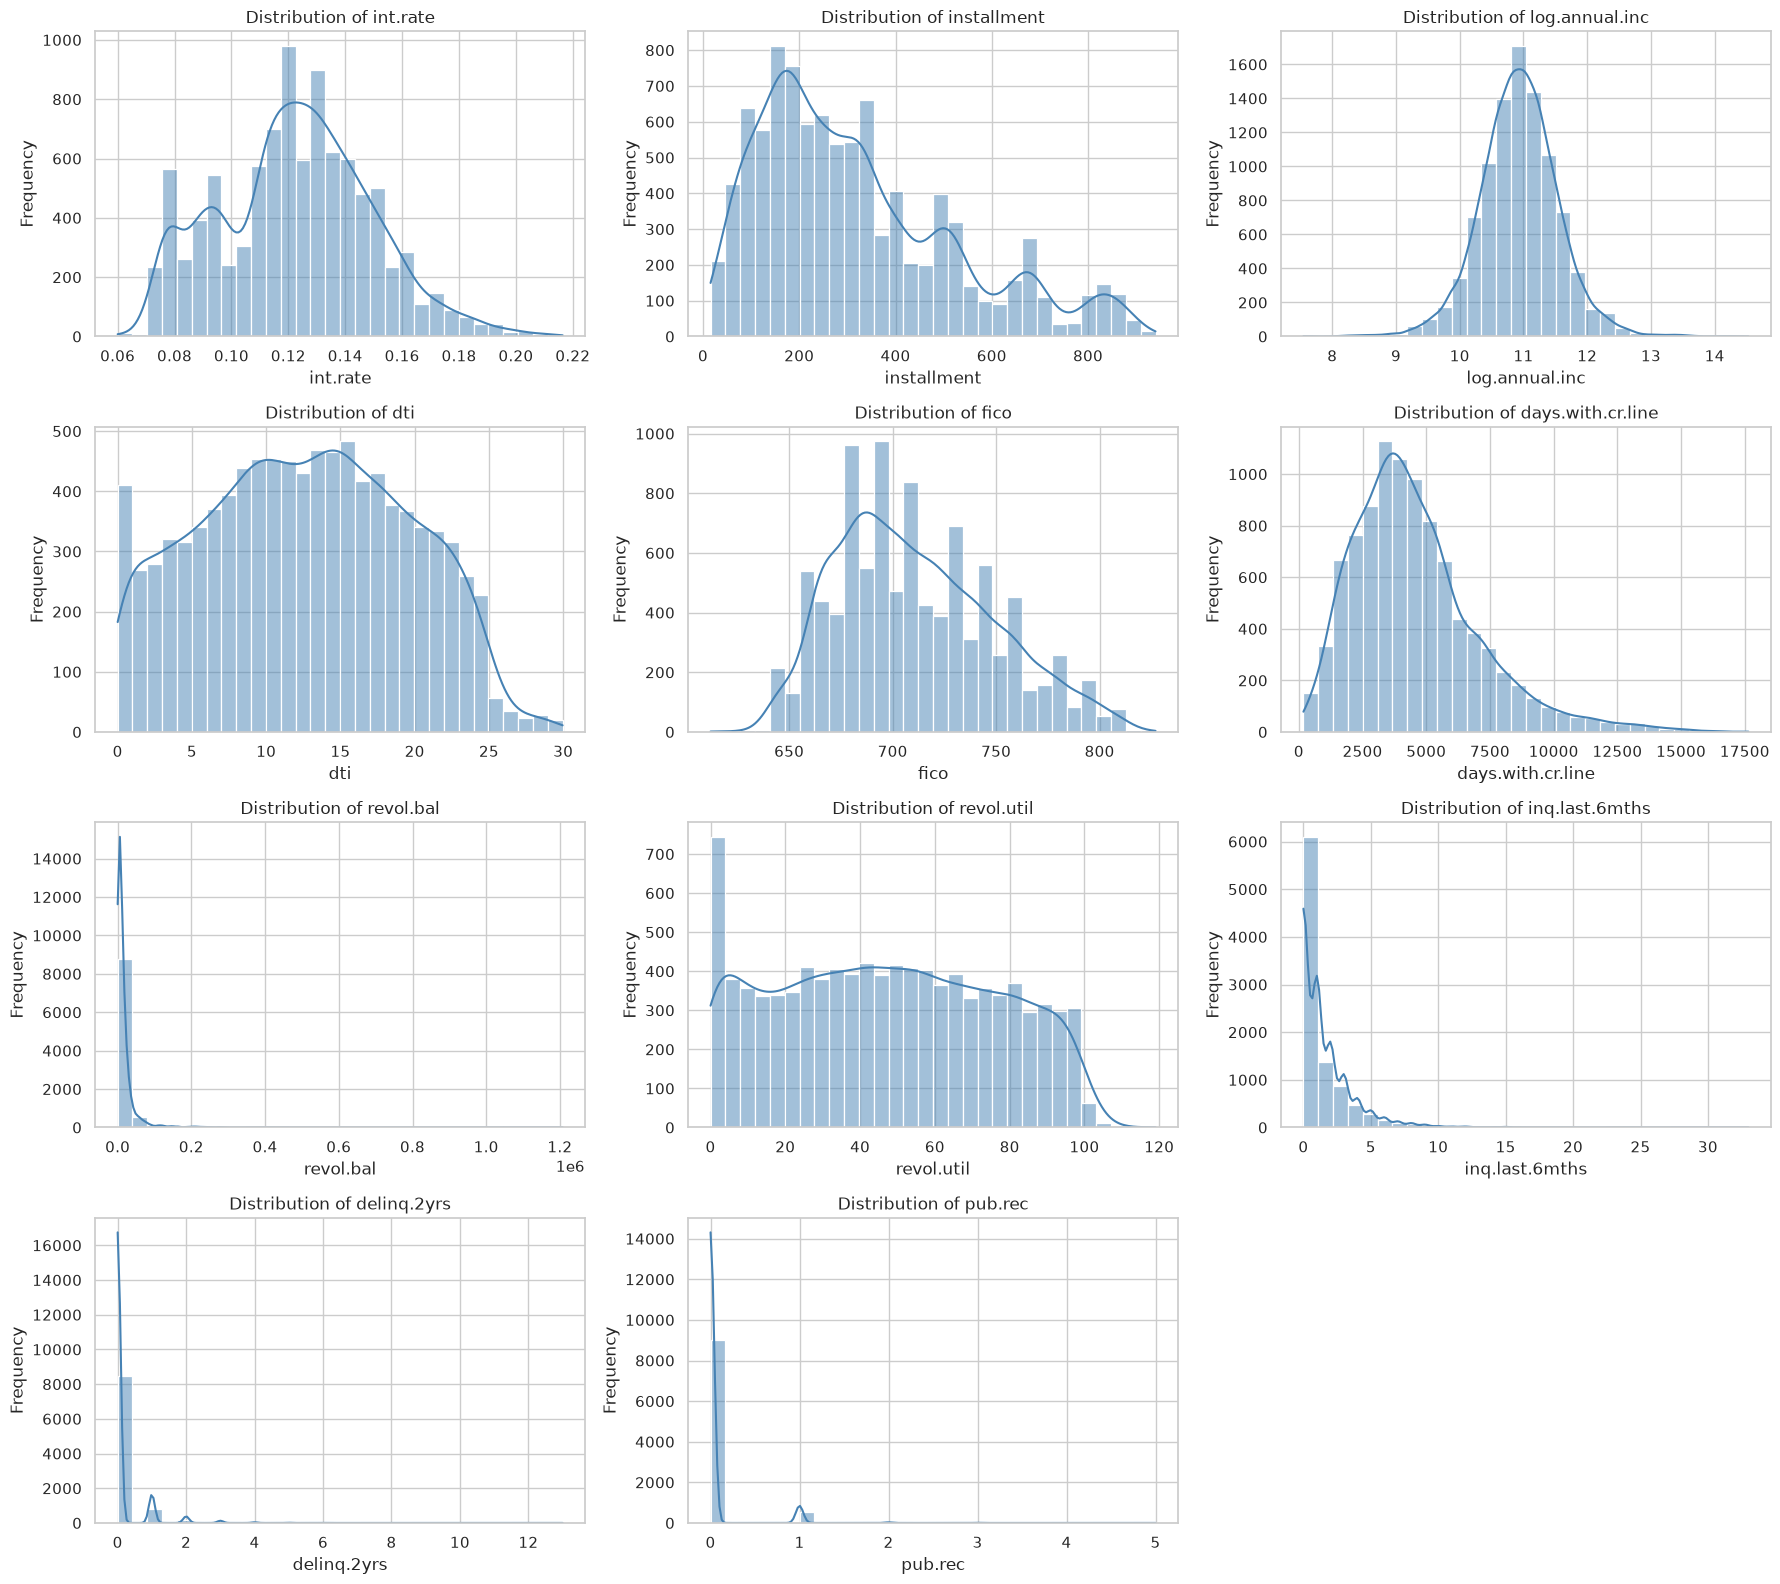

In [7]:
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
                'delinq.2yrs', 'pub.rec']

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../output/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations:** `revol.bal`, `dti`, `days.with.cr.line`, and
`inq.last.6mths` are right-skewed with long tails; `delinq.2yrs` and
`pub.rec` are extremely concentrated at 0 (most borrowers have none) —
these behave more like sparse count/flag variables than continuous ones.
`fico`, `int.rate`, and `log.annual.inc` are closer to bell-shaped.

### 4.3 Correlation structure

Two views: (1) all application-time numeric fields plus `default` and the
post-outcome KPI fields (to show *why* the KPI fields must be excluded from
modeling), and (2) application-time predictors only.


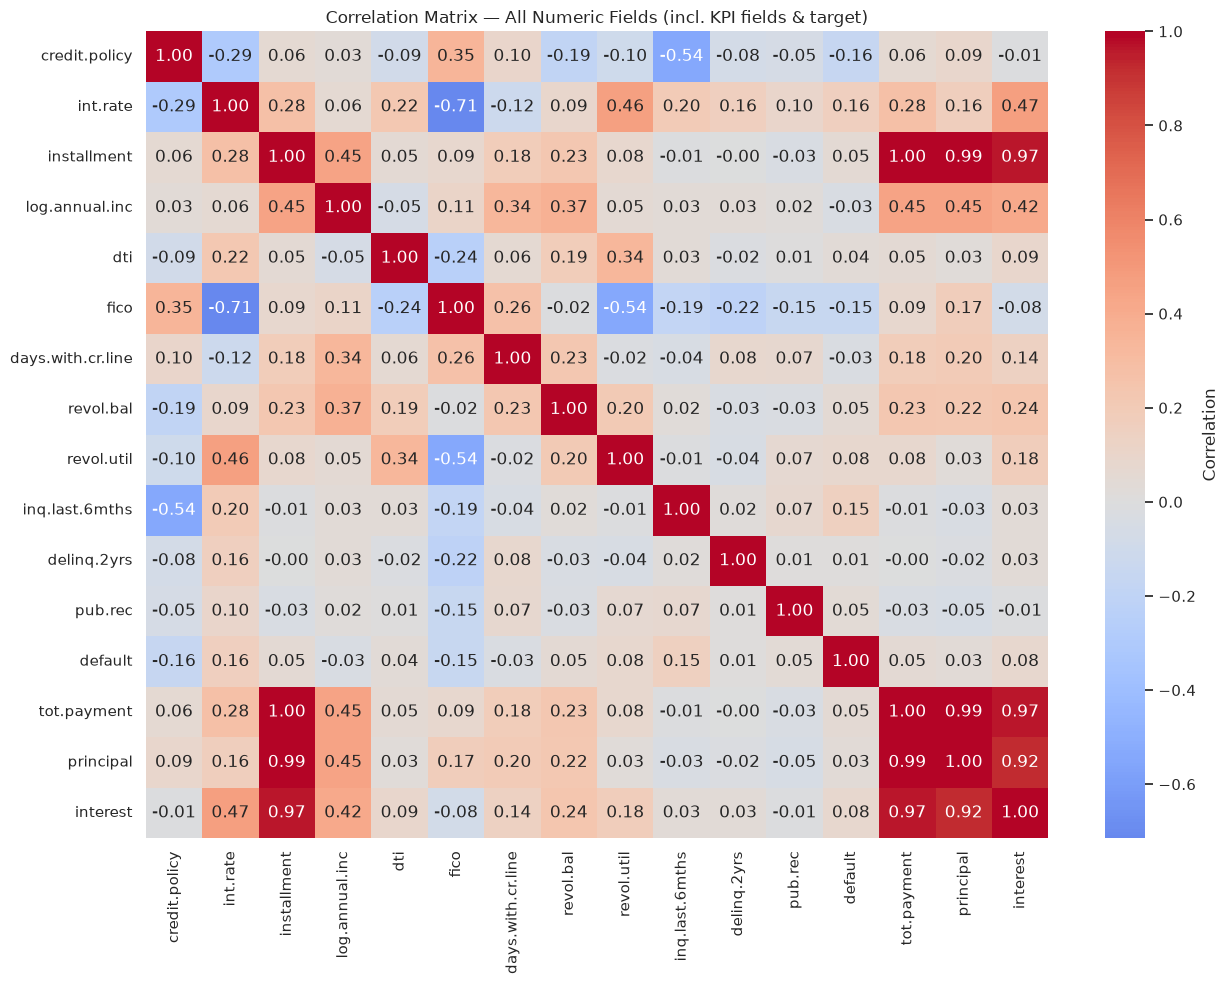

In [8]:
full_numeric = df.select_dtypes(include=[np.number])
corr_full = full_numeric.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields (incl. KPI fields & target)')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()


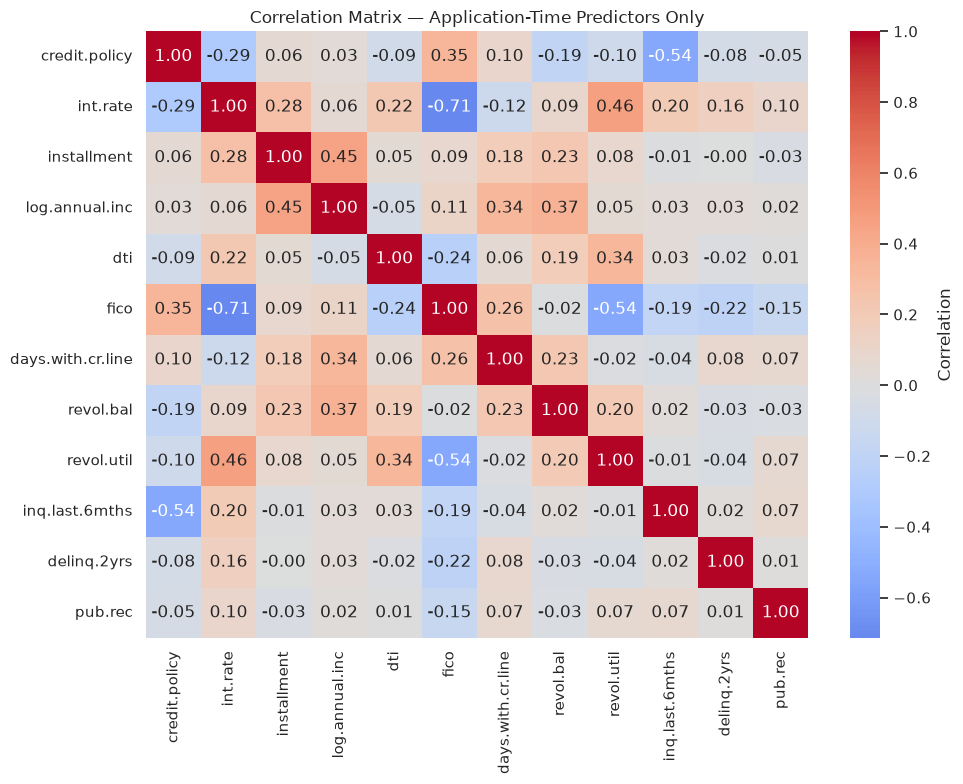

In [9]:
predictor_cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
                   'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
                   'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

corr_predictors = df[predictor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_predictors, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Application-Time Predictors Only')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_predictors.png', dpi=150, bbox_inches='tight')
plt.show()


**Key correlated pairs** (as anticipated by the case):
- `int.rate` vs. `fico`: strongly negative — LendingClub prices risk into
  the rate.
- `int.rate` vs. `revol.util`: positive — utilization is part of the risk
  assessment behind the rate.
- The KPI fields `tot.payment`/`principal`/`interest` are (by construction)
  almost perfectly correlated with `installment`/`int.rate` — confirming
  they carry no independent information and must be excluded as predictors.

`int.rate` vs. `fico` (r ≈ −0.71) is the single strongest correlation among
all application-time numeric fields — stronger than any other pair in the
matrix above. We use this directly in Section 5.1 to decide which variable
to keep for the **unsupervised** (clustering/PCA) analysis in this update.

### 4.4 How does the default rate vary with key variables?

This directly answers the case's descriptive-statistics question: how do
default rates vary with credit score, interest rate, loan purpose, or
debt-to-income ratio? We use 100%-normalized bucket charts so the height of
the red segment is directly the **default rate** for that bucket.


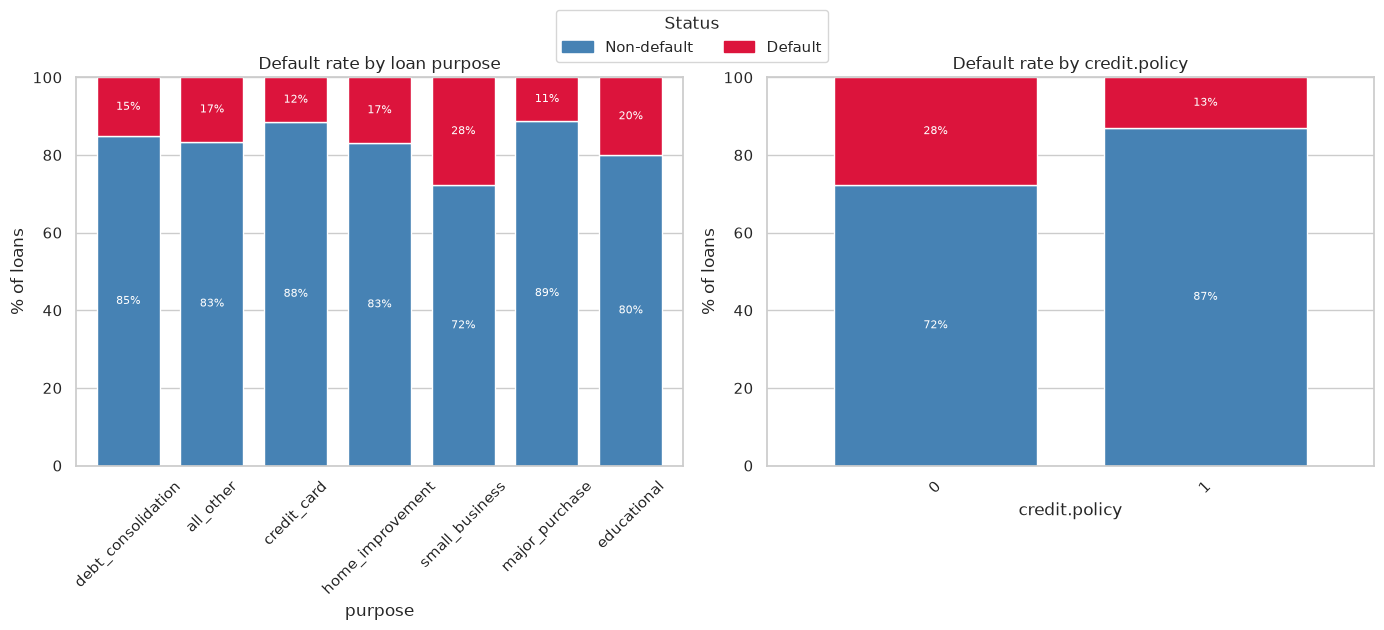

In [10]:
default_palette = {0: 'steelblue', 1: 'crimson'}
default_labels = {0: 'Non-default', 1: 'Default'}

def plot_100pct_stacked(ax, series, default, title, xlabel, order=None):
    tab = pd.crosstab(series, default, normalize='index') * 100
    if order is not None:
        tab = tab.reindex(order)
    tab = tab.rename(columns=default_labels)
    tab[[default_labels[0], default_labels[1]]].plot(
        kind='bar', stacked=True, ax=ax,
        color=[default_palette[0], default_palette[1]], width=0.75, legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% of loans')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        labels = [f'{v:.0f}%' if v >= 5 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = df['purpose'].value_counts().index
plot_100pct_stacked(axes[0], df['purpose'], df['default'], 'Default rate by loan purpose', 'purpose', order=order)
plot_100pct_stacked(axes[1], df['credit.policy'], df['default'], 'Default rate by credit.policy', 'credit.policy')
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.06), ncol=2)
plt.tight_layout()
plt.savefig('../output/categorical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


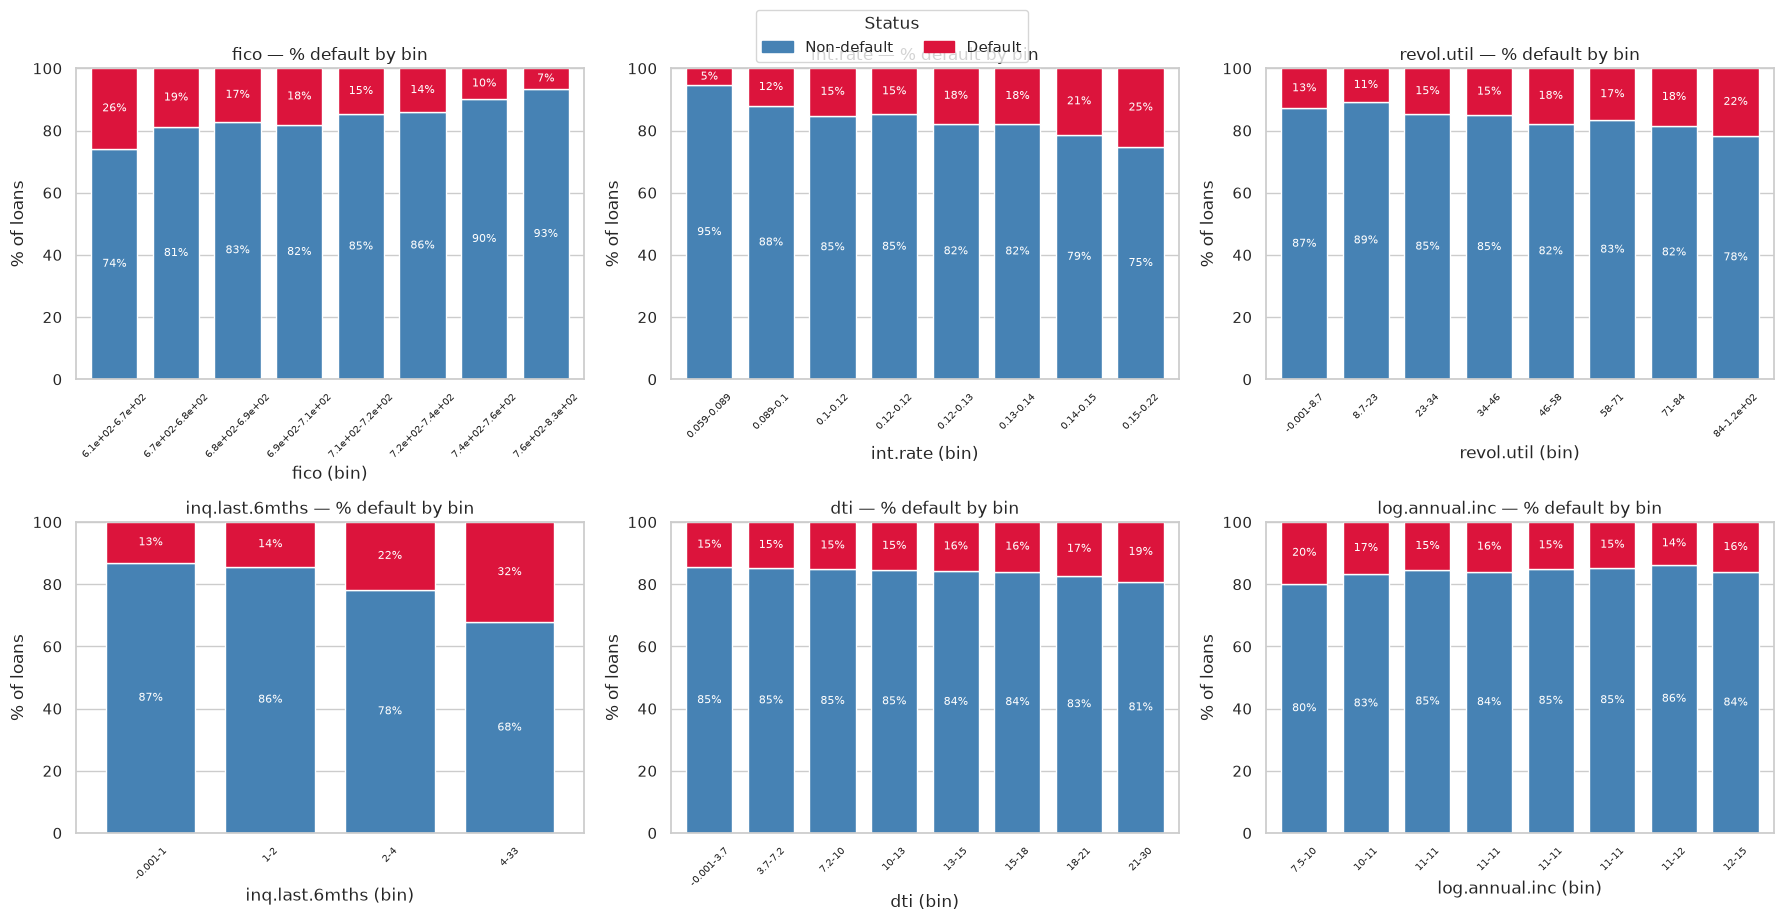

In [11]:
default_drivers = ['fico', 'int.rate', 'revol.util', 'inq.last.6mths', 'dti', 'log.annual.inc']
n_bins = 8
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(default_drivers):
    binned = pd.qcut(df[col], q=n_bins, duplicates='drop')
    bin_order = binned.cat.categories
    plot_100pct_stacked(axes[i], binned, df['default'], f'{col} — % default by bin', f'{col} (bin)', order=bin_order)
    axes[i].set_xticklabels([f'{iv.left:.2g}-{iv.right:.2g}' for iv in bin_order], fontsize=7)
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.03), ncol=2)
plt.tight_layout()
plt.savefig('../output/numerical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


**Findings:**
- **`purpose`**: `small_business` loans default at 27.8% — roughly 2.5x the
  rate of `major_purchase`/`credit_card` loans (~11%).
- **`credit.policy`**: loans failing LendingClub's own underwriting default
  at 27.8% vs. 13.2% for those that pass — a real but imperfect filter.
- **`fico`**: the cleanest monotonic gradient — default falls from ~26% in
  the lowest FICO octile to ~7% in the highest (~4x spread).
- **`int.rate`**: mirrors FICO, rising from ~5% to ~25% across octiles,
  since it is set as a function of assessed risk.
- **`revol.util`**: rises from ~11–13% to ~22% at the highest utilization —
  an over-leverage signal.
- **`inq.last.6mths`**: the steepest gradient of all, roughly tripling from
  ~13% (0–1 inquiries) to ~32% (5+ inquiries) — recent credit-shopping is a
  strong red flag.
- **`dti`** and **`log.annual.inc`**: comparatively flat, with only a mild
  uptick in the riskiest extreme bin — weaker standalone predictors.

These confirm the hypotheses in Section 3.3 and motivate the variable
choices for clustering and PCA below.


## 5. K-Means Clustering

Clustering lets us use the *co-varying* patterns among borrower attributes
to pick out naturally occurring segments of loan applications, independent
of the default label. These segments can later be used to stratify
modeling, spot-check risk models, or target growth/marketing efforts.

### 5.1 Variable selection

**Scope constraint:** every variable considered for clustering and PCA in
this update — with no exception — is known **at the time of the funding
decision** (Section 3.2). `default`, `tot.payment`, `principal`, and
`interest` are never used as clustering/PCA inputs anywhere below; `default`
is only ever used afterward, to describe a cluster's realized outcome.

Following the case's own example set (interest rate, installment, annual
income, FICO score, revolving balance, revolving utilization), our starting
point is the **continuous, application-time numeric variables** that showed
meaningful spread and default-rate gradients in Section 4:

`int.rate`, `installment`, `log.annual.inc`, `dti`, `fico`,
`days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths`

We deliberately **exclude** `credit.policy` (a binary underwriting flag,
not a continuous borrower attribute — and effectively downstream of the
other variables), and `delinq.2yrs`/`pub.rec` (Section 4.2 showed these are
overwhelmingly zero across the sample, so they carry almost no variance for
Euclidean-distance-based clustering and would just add noise).

**Correlation-based pruning.** Section 4.3 flagged `int.rate` vs. `fico` as
the single strongest correlation among application-time numeric fields
(r ≈ −0.71, i.e. roughly 51% shared variance) — clearly the standout pair,
well above the next-strongest (`fico` vs. `revol.util`, r ≈ −0.54). Keeping
both in a Euclidean-distance method would effectively double-weight the same
underlying risk signal. We resolve this by **dropping `int.rate`** and
keeping `fico`:

- `fico` is a primitive, exogenous borrower attribute (a credit-bureau
  score); `int.rate` is Lending Club's own **derived output** — a decision
  the platform already made using `fico` plus other risk factors (some not
  in our data). Clustering on `int.rate` risks rediscovering Lending Club's
  existing pricing tiers rather than revealing independent structure.
- Dropping it lets us use `int.rate` afterward as an **external check**: if
  the clusters we find (built with no pricing information at all) still line
  up with Lending Club's own rates and with realized default rates, that is
  stronger evidence the segments are real — and any place they *don't* line
  up is a potential blind spot in current pricing (see Section 5.5).

**Final clustering/PCA variable set (8 variables, all known at application):**

`installment`, `log.annual.inc`, `dti`, `fico`, `days.with.cr.line`,
`revol.bal`, `revol.util`, `inq.last.6mths`


In [12]:
cluster_vars = ['installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths']
# int.rate deliberately excluded — see Section 5.1 (r ~ -0.71 with fico,
# and int.rate is Lending Club's own derived risk output, not a primitive
# borrower attribute). Retained only as a post-hoc validation metric below.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])
print(f"Clustering on {X_scaled.shape[0]} loans x {X_scaled.shape[1]} scaled features")


Clustering on 9578 loans x 8 scaled features


### 5.2 Choosing the number of clusters (elbow + silhouette)

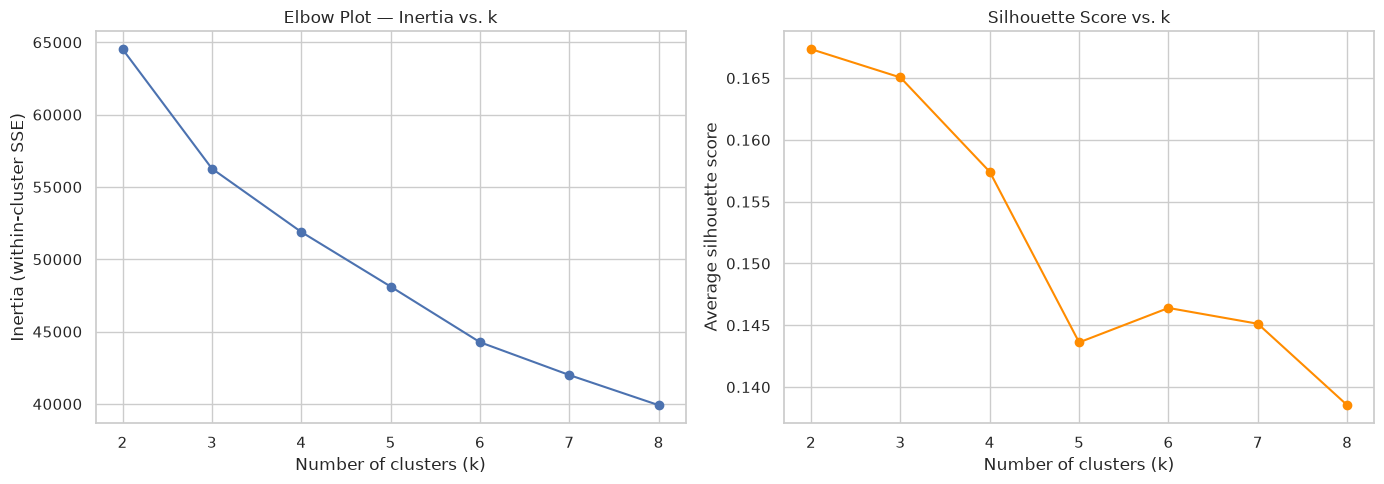

k=2: inertia=64527, silhouette=0.1673
k=3: inertia=56269, silhouette=0.1650
k=4: inertia=51891, silhouette=0.1574
k=5: inertia=48116, silhouette=0.1436
k=6: inertia=44268, silhouette=0.1464
k=7: inertia=41999, silhouette=0.1451
k=8: inertia=39917, silhouette=0.1385


In [13]:
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Plot — Inertia vs. k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].grid(True)

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Average silhouette score')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('../output/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.0f}, silhouette={sil:.4f}")


With `int.rate` removed, both curves are, if anything, even flatter than
before: silhouette peaks mildly at k=2–3 (~0.165–0.167) and decays slowly
after that, with no sharp elbow — again typical of real borrower data with
overlapping, continuous risk gradients rather than tight natural clusters.
We keep **k=4**: it costs little silhouette quality relative to k=2/3 while
giving enough granularity to separate out the small, high-balance outlier
segment (below) and to produce named, actionable archetypes for the ExCo,
consistent with the case's own suggested 3–4 example segments.

### 5.3 Fit K-means with k=4 and profile the clusters


In [14]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_sizes_pct = (cluster_sizes / len(df) * 100).round(1)
print("Cluster sizes:")
display(pd.DataFrame({'n_loans': cluster_sizes, '% of loans': cluster_sizes_pct}))

cluster_profile = df.groupby('cluster')[cluster_vars].mean().round(2)
cluster_profile['default_rate_%'] = (df.groupby('cluster')['default'].mean() * 100).round(1)
cluster_profile['credit_policy_pass_%'] = (df.groupby('cluster')['credit.policy'].mean() * 100).round(1)
cluster_profile['int.rate_%'] = (df.groupby('cluster')['int.rate'].mean() * 100).round(2)  # NOT a clustering input — shown only as external validation
display(cluster_profile)


Cluster sizes:


,n_loans,% of loans
cluster,,
0,188,2.0
1,3785,39.5
2,2768,28.9
3,2837,29.6


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,default_rate_%,credit_policy_pass_%,int.rate_%
cluster,,,,,,,,,,,
0,504.70,12.00,16.68,716.04,7097.26,190815.01,56.76,2.04,28.2,19.7,13.01
1,201.65,10.54,13.52,689.08,3110.50,8022.35,52.69,1.93,18.9,70.9,12.95
2,474.18,11.29,15.49,698.88,5611.15,26038.96,66.79,1.47,18.3,83.0,13.54
3,312.15,11.03,8.31,751.22,5302.73,8349.77,18.77,1.18,9.2,94.9,10.05


### 5.4 Naming the clusters — parallel-coordinates plot of (standardized) cluster centers

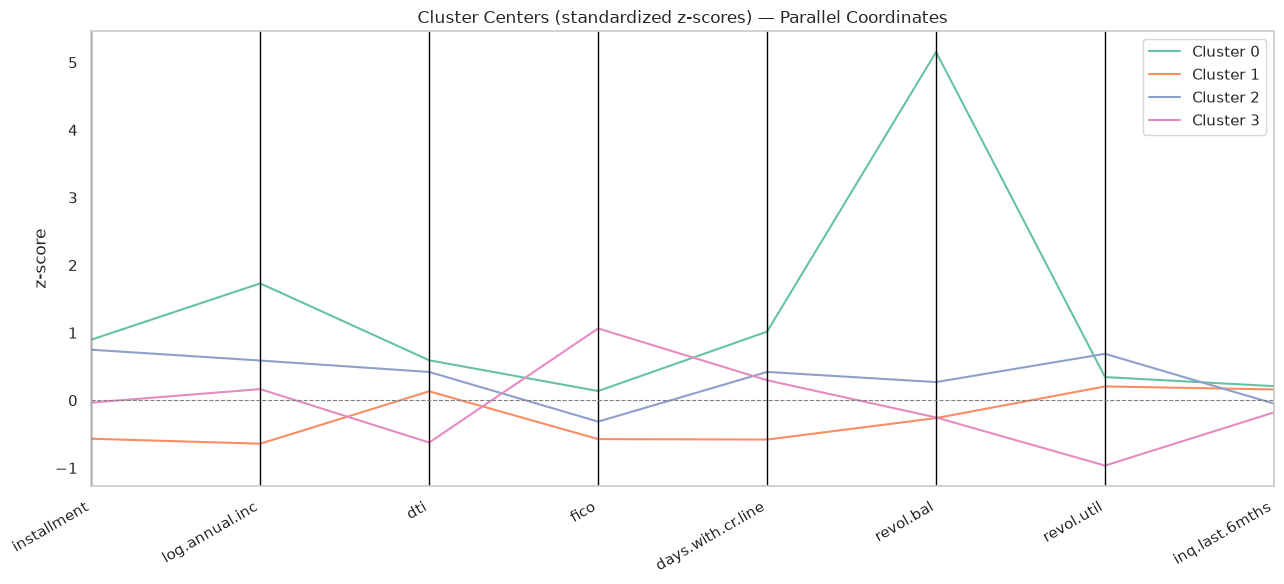

In [15]:
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_vars)
centers_df['cluster'] = [f'Cluster {i}' for i in range(len(centers_df))]

plt.figure(figsize=(13, 6))
parallel_coordinates(centers_df, 'cluster', color=sns.color_palette('Set2', 4))
plt.title('Cluster Centers (standardized z-scores) — Parallel Coordinates')
plt.ylabel('z-score')
plt.xticks(rotation=30, ha='right')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../output/kmeans_parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()


**Cluster interpretation (naming), based on the standardized centers and
raw-unit profile table above.** `int.rate` was **not** used to build these
clusters — it is shown only as a post-hoc check against Lending Club's own
pricing:

| Cluster | Size | Distinguishing features (clustering inputs only) | `int.rate` (not an input) | Default rate | Name |
|---|---|---|---|---|---|
| **3** | 2,837 (30%) | Highest `fico` (~751), lowest `dti` (~8.3), lowest `revol.util` (~19%), fewest `inq.last.6mths`; 95% pass `credit.policy` | 10.05% (lowest) | **9.2%** (safest) | **"High-FICO, low-utilization safe borrowers"** |
| **1** | 3,785 (40%, largest) | Smallest loans (`installment` ~$202), lowest income, shortest credit history (~3,110 days), lowest `fico` (~689) | 12.95% | 18.9% | **"Short-history, small-loan borrowers"** |
| **2** | 2,768 (29%) | Largest installments (~$474) among the "typical" clusters, highest `revol.util` (~67%), above-average income, below-average `fico` | 13.54% (highest) | 18.3% | **"High-utilization revolvers"** |
| **0** | 188 (2%, small outlier segment) | Extreme `revol.bal` (z ≈ +5.2, mean ~$190.8k), highest income, longest credit history, highest `dti`; only 20% pass `credit.policy` | 13.01% | **28.2%** (riskiest) | **"High-income jumbo revolvers"** |

The same four archetypes we found with `int.rate` included (Section 5,
first pass) re-emerge almost identically once it is dropped — reassuring,
since it means these segments are grounded in stable borrower attributes,
not an artifact of also feeding in Lending Club's pricing signal.

**A new finding this pass surfaces: `int.rate` does not fully track realized
risk across these segments.** Ranking clusters by average `int.rate` gives
3 < 1 < 0 < 2 (Cluster 2 is priced *highest* on average), but ranking by
*realized* default rate gives 3 < 2 < 1 < 0 (Cluster 0 defaults *most*).
Cluster 0 — the high-income jumbo-revolver outlier — has the worst default
rate in the book (28.2%) yet is priced **below** Cluster 2 (13.01% vs.
13.54%). That is a potential blind spot in current pricing: a small (2% of
volume) but disproportionately risky segment that Lending Club's existing
rate-setting does not appear to price high enough relative to its actual
loss experience.

### 5.5 How this clustering guides future modeling

- It gives a **natural, unsupervised risk stratification built with zero
  pricing information** — useful to sanity-check that a later logistic
  regression / tree model's predicted risk ranks track these segments, and
  now also directly comparable against Lending Club's *own* pricing.
- The **Cluster 0 / Cluster 2 pricing-vs-default mismatch** above is a
  concrete, ExCo-relevant lead: worth testing in Update 2 whether a
  `revol.bal`-driven flag (or cluster membership itself) adds predictive
  power for default *beyond* what `int.rate` already captures — if so, it
  is a case for repricing or tighter screening of this specific segment.
- Cluster 1 (short-history, small-loan borrowers) is both the **largest
  segment (40% of volume)** and above-average risk — a natural target for
  tighter screening rules and for the CMO's growth strategy (e.g.,
  requiring longer credit history or smaller initial loan sizes for this
  segment).
- Segment membership itself could become an **engineered categorical
  feature** for the classification models in Update 2 — and, unlike in the
  first pass, it would add information genuinely independent of `int.rate`
  rather than partially re-deriving it.


## 6. Principal Component Analysis (PCA)

PCA highlights weighted combinations of the numeric variables that capture
the directions of highest variability among loans — a complementary,
continuous view to the discrete segments found by K-means.

### 6.1 Variable selection

We use the **same 8 application-time, numeric variables as the K-means
analysis** (Section 5.1) — `installment`, `log.annual.inc`, `dti`, `fico`,
`days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths` — for the
same reasons and the same correlation-based exclusion of `int.rate`. Using
an identical variable set lets us compare the clustering and PCA views of
the same feature space directly, and — as in Section 5 — lets us treat
`int.rate` and `default` purely as external, post-hoc checks on what PCA
finds, never as inputs to it.


In [16]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

print('Explained variance ratio per component:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'PC{i+1}: {ratio*100:.2f}%')
print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_explained_variance):
    print(f'PC{i+1}: {cum*100:.2f}%')

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['default'] = df['default'].values
pca_df['cluster'] = df['cluster'].values
display(pca_df.head())


Explained variance ratio per component:
PC1: 24.77%
PC2: 23.12%
PC3: 12.98%
PC4: 11.18%
PC5: 9.04%
PC6: 8.58%
PC7: 5.73%
PC8: 4.59%

Cumulative explained variance:
PC1: 24.77%
PC2: 47.90%
PC3: 60.88%
PC4: 72.06%
PC5: 81.10%
PC6: 89.68%
PC7: 95.41%
PC8: 100.00%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,default,cluster
0,2.146251,0.210332,-0.700960,-0.672079,1.756365,0.179680,-0.383750,0.051456,0,2
1,0.059457,-0.870066,-0.762315,-0.517036,-0.561036,0.495818,0.354790,0.606763,0,1
2,-0.764727,0.041934,-0.099588,-0.110597,0.344577,-0.185407,-0.516415,-1.100793,0,1
3,-0.000933,-0.369294,-0.039891,-0.704260,-1.232486,0.354183,0.491119,0.802900,0,1
4,-0.509496,-0.571864,-0.474836,-0.120891,-0.552862,-0.248133,1.310729,-0.856565,0,1


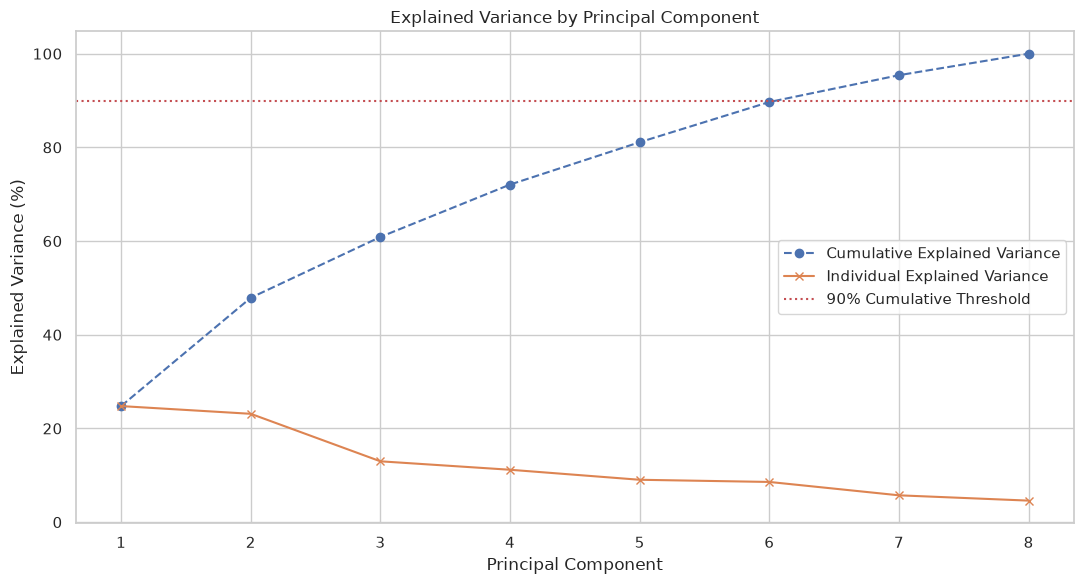

In [17]:
num_components = range(1, len(cumulative_explained_variance) + 1)

plt.figure(figsize=(11, 6))
plt.plot(num_components, cumulative_explained_variance * 100, marker='o', linestyle='--',
         label='Cumulative Explained Variance')
plt.plot(num_components, explained_variance_ratio * 100, marker='x', linestyle='-',
         label='Individual Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Component')
plt.grid(True)
plt.xticks(num_components)
plt.axhline(y=90, color='r', linestyle=':', label='90% Cumulative Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('../output/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Model-driven interpretation — variable loadings

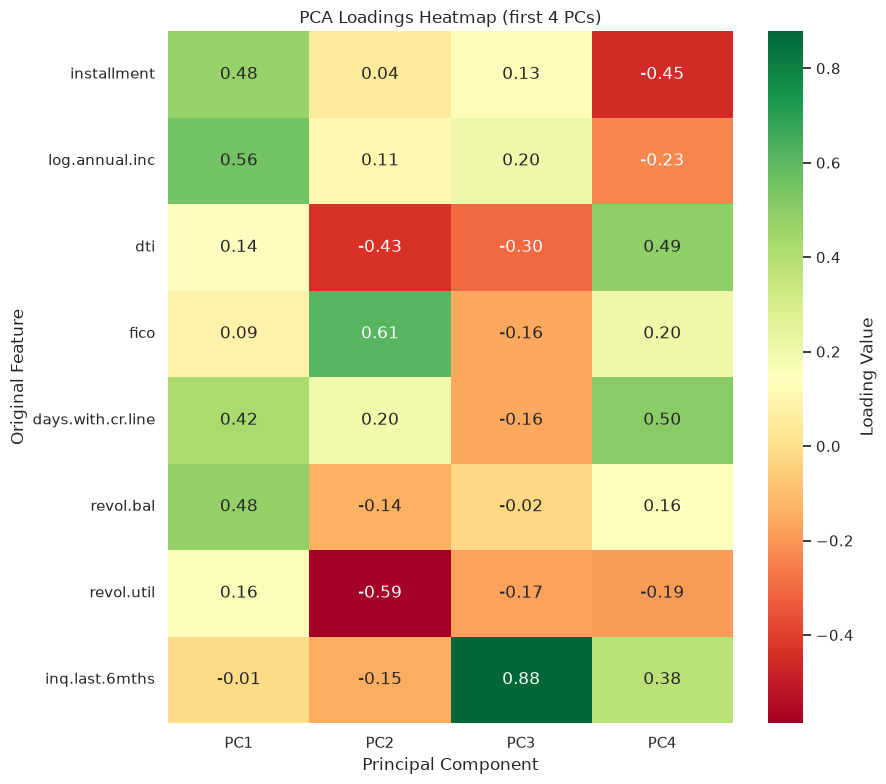

Top |loadings| for PC1:
  log.annual.inc: +0.556
  revol.bal: +0.482
  installment: +0.476
  days.with.cr.line: +0.422

Top |loadings| for PC2:
  fico: +0.612
  revol.util: -0.586
  dti: -0.432
  days.with.cr.line: +0.199

Top |loadings| for PC3:
  inq.last.6mths: +0.878
  dti: -0.301
  log.annual.inc: +0.204
  revol.util: -0.170



In [18]:
loadings_df = pd.DataFrame(pca.components_, columns=cluster_vars,
                            index=[f'PC{i+1}' for i in range(pca.n_components_)])

n_show = min(4, loadings_df.shape[0])
plt.figure(figsize=(9, 8))
sns.heatmap(loadings_df.iloc[:n_show].T, annot=True, cmap='RdYlGn', fmt=".2f",
            cbar_kws={'label': 'Loading Value'})
plt.title(f'PCA Loadings Heatmap (first {n_show} PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()
plt.savefig('../output/pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings_df.loc[pc].abs().sort_values(ascending=False).head(4)
    print(f"Top |loadings| for {pc}:")
    for feat in top.index:
        print(f"  {feat}: {loadings_df.loc[pc, feat]:+.3f}")
    print()


**PC1 ("scale / establishment axis", 24.8% of variance):** dominant
positive loadings on `log.annual.inc` (+0.56), `revol.bal` (+0.48),
`installment` (+0.48), and `days.with.cr.line` (+0.42); `fico` loads almost
at zero (+0.09). High PC1 = higher income, larger absolute revolving
balance, bigger installment, longer credit history — i.e. a larger, more
established borrower. Notably, with `int.rate` removed, this is now a
**near-pure scale axis with almost no risk signal in it** (`fico`'s loading
is essentially negligible) — a cleaner separation than in the first pass,
where `int.rate`'s dominant loading pulled a risk flavor into PC1.

**PC2 ("safety axis", 23.1% of variance, cumulative 47.9%):** dominant
positive loading on `fico` (+0.61), and dominant negative loadings on
`revol.util` (−0.59) and `dti` (−0.43). High PC2 = higher FICO, lower
revolving utilization, lower debt-to-income — i.e. a **safer** borrower
(the sign is the opposite convention from the first pass's risk axis, but
the underlying variables — `fico`, `revol.util`, `dti` — are the same ones
Section 4.3's correlation matrix flagged as `int.rate`'s closest substitutes).

**PC3** (13.0% of variance) is dominated almost entirely by
`inq.last.6mths` (+0.88) — a near single-variable "credit-shopping
intensity" component, largely orthogonal to both PC1 and PC2.

Together PC1+PC2 explain about 48% of the variance; 7 of the 8 components
are needed to reach 90% (variance is spread fairly evenly — consistent with
8 genuinely distinct underlying borrower attributes rather than a few
redundant ones, which is itself a mild confirmation that dropping `int.rate`
removed a genuinely redundant variable without leaving other redundancy
behind).

### 6.3 Biplot of PC1 vs. PC2, colored by K-means cluster


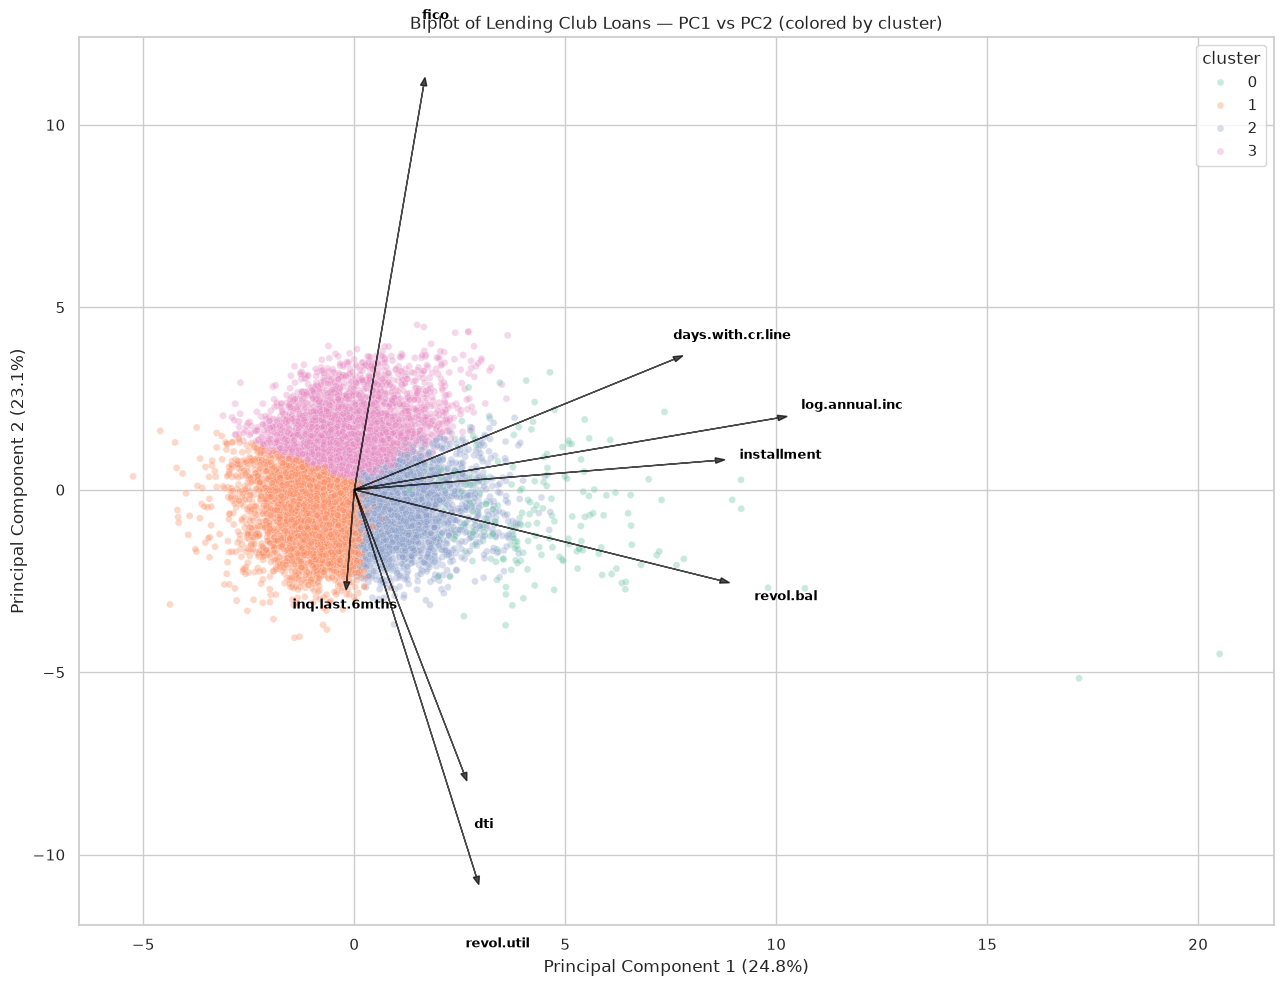

In [19]:
loadings = pca.components_
feature_names = cluster_vars

fig = plt.figure(figsize=(13, 10))
n_clusters = pca_df['cluster'].nunique()
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['cluster'],
                 palette=sns.color_palette('Set2', n_clusters), alpha=0.35, s=25)

scale = np.abs(pca_df[['PC1', 'PC2']]).max().max() * 0.9
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[0, i] * scale, loadings[1, i] * scale,
              color='black', alpha=0.7, head_width=0.15, length_includes_head=True)
    plt.text(loadings[0, i] * scale * 1.15, loadings[1, i] * scale * 1.15, feature,
              color='black', ha='center', va='center', fontsize=9, fontweight='bold')

plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('Biplot of Lending Club Loans — PC1 vs PC2 (colored by cluster)')
plt.legend(title='cluster', loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('../output/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


Coloring the same biplot by **K-means cluster** (Section 5) instead of by
`default` gives a direct, visual check of whether the two unsupervised
methods agree — and they do, even more cleanly than with `int.rate`
included. Mean PC1/PC2 position per cluster:

| Cluster | Mean PC1 (scale) | Mean PC2 (safety) | Reading |
|---|---|---|---|
| **3** — High-FICO, low-utilization safe borrowers | −0.07 (average) | **+1.63** (far highest) | Stands apart almost entirely on the safety axis, near-average on scale — exactly as named. |
| **1** — Short-history, small-loan borrowers | **−1.00** (lowest) | −0.73 | Lowest scale score — smallest loans, shortest credit history, lowest income — and below-average safety. |
| **2** — High-utilization revolvers | 1.13 | −0.63 | Above-average scale, below-average safety — similar safety to Cluster 1 but larger loans. |
| **0** — High-income jumbo revolvers | **4.45** (far highest) | −0.69 | The clear scale outlier — consistent with its extreme `revol.bal` — with below-average safety on top of that. |

The structure is remarkably clean: **PC2 alone cleanly separates the safe
cluster (3) from the other three**, which all sit at similar, below-average
safety (−0.6 to −0.7); **PC1 then separates those other three by scale**
(jumbo revolvers ≫ high-utilization revolvers > short-history small-loan
borrowers). The four clusters occupy distinct, contiguous regions of the
plane rather than overlapping randomly — two *independently fitted*
unsupervised methods (K-means on 8 raw scaled features, PCA on the same 8
features, neither given `int.rate` or `default`) recover the same
underlying structure, which is exactly the kind of convergence that makes
this variable shortlist defensible to the ExCo.


### 6.4 Data-driven interpretation — examining extreme points

In [20]:
inspect_cols = cluster_vars + ['purpose', 'credit.policy', 'default', 'int.rate', 'cluster']
# int.rate and cluster are shown for context only — neither was a PCA input

for pc in ['PC1', 'PC2']:
    idx_max, idx_min = pca_df[pc].idxmax(), pca_df[pc].idxmin()
    print(f"=== Extreme HIGH {pc} (loan #{idx_max}, {pc}={pca_df.loc[idx_max, pc]:.2f}) ===")
    display(df.loc[[idx_max], inspect_cols])
    print(f"=== Extreme LOW {pc} (loan #{idx_min}, {pc}={pca_df.loc[idx_min, pc]:.2f}) ===")
    display(df.loc[[idx_min], inspect_cols])


=== Extreme HIGH PC1 (loan #9535, PC1=20.51) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
9535,831.52,12.765688,11.38,717,8520.041667,1207359,56.0,7,small_business,0,1,0.1496,0


=== Extreme LOW PC1 (loan #7897, PC1=-5.24) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
7897,15.91,7.600902,0.0,702,238.958333,0,0.0,6,all_other,0,1,0.0901,1


=== Extreme HIGH PC2 (loan #113, PC2=4.52) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
113,64.96,11.608236,0.22,812,16213.0,50,0.3,0,debt_consolidation,1,0,0.0712,3


=== Extreme LOW PC2 (loan #9042, PC2=-5.17) ===


,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default,int.rate,cluster
9042,735.06,13.304685,14.39,672,7620.0,952013,99.0,6,small_business,0,0,0.2011,0


**Reading the extremes confirms the model-driven story:**

- **Highest PC1** loan (Cluster 0): `installment` $831.52, `revol.bal` at
  the data's maximum ($1,207,359), high income, `fico` 717, a
  `small_business` loan that **fails** `credit.policy` — exactly the
  extreme-scale profile PC1 is built to flag. `int.rate` was 14.96% (not a
  PCA input) and the loan **did** default.
- **Lowest PC1** loan (Cluster 1): `installment` $15.91 — essentially the
  smallest loan in the data — with near-zero reported income (log 7.60,
  ≈ $2,000/yr, a likely data-quality flag), zero revolving balance, and a
  decent `fico` (702). Despite the healthy FICO, this loan **did** default,
  a reminder that PC1 (scale) says nothing about safety on its own.
- **Highest PC2** loan (Cluster 3): `fico` 812 (near the data's maximum),
  `revol.util` 0.3%, `dti` 0.22, zero inquiries — a textbook ultra-safe
  borrower. `int.rate` was 7.12%, the lowest of any example here, and the
  loan was **paid in full**.
- **Lowest PC2** loan (Cluster 0): `fico` 672, `revol.util` 99%, `dti`
  14.39, `revol.bal` ≈ $952k — the riskiest-looking profile on paper, and
  Lending Club evidently agreed: `int.rate` was 20.11%, the highest of any
  example here. Yet this loan **did not** default — a useful reminder that
  PC2, like PC1, describes a risk *tendency* in the population, not a
  certainty for any one loan, and that Lending Club's pricing does track
  individual extreme cases even where Section 5's cluster-level averages
  suggested a gap.

These examples show PC1 and PC2 behave as intended (a scale axis and a
safety axis, respectively), reproduce the same borrower archetypes found
independently by K-means, and surface individual loans worth spot-checking
for data quality (e.g., the very low reported income case).

### 6.5 How this PCA guides future modeling

- **PC2 is a ready-made, single-number safety score** built purely from
  unsupervised structure with **no pricing information at all** — a useful
  baseline/sanity-check against the logistic regression coefficients we
  will estimate in Update 2 (do `fico`, `revol.util`, and `dti` dominate
  there too?).
- **Near-orthogonality of PC1 and PC2** suggests `fico`/`revol.util`/`dti`
  (safety) and `log.annual.inc`/`installment`/`days.with.cr.line`/
  `revol.bal` (scale) are two largely independent dimensions — both may be
  worth retaining as predictors rather than assuming one subsumes the
  other. Removing `int.rate` made this separation noticeably cleaner than
  in the first pass, where its dominant loading blurred a risk flavor into
  PC1.
- The **PCA loadings mirror the correlation findings** (Section 4.3), and
  the cluster-colored biplot in Section 6.3 shows the **K-means segments**
  (Section 5) occupying distinct, contiguous regions of the PC1–PC2 plane
  — three independent views of the data (correlation, clustering, PCA),
  built entirely from application-time variables, converge on the same
  handful of variables (`fico`, `revol.util`, `dti`, plus scale variables
  like `log.annual.inc` and `revol.bal`) as the primary structure in the
  data.
- The **Cluster 0 pricing gap** identified in Section 5.4 (highest default
  rate, only third-highest `int.rate`) is visible here too: Cluster 0 sits
  at below-average PC2 (safety) alongside Clusters 1 and 2, yet its
  realized default rate is meaningfully worse than either — worth carrying
  into Update 2 as a specific hypothesis to test with a supervised model.
- PCA could also be used for **dimensionality reduction** if
  multicollinearity becomes a problem in the logistic regression (e.g.,
  using PC1/PC2 scores directly as predictors), though we would trade off
  some interpretability for the ExCo audience.


## 7. Synthesis — Update 1 Summary for the ExCo

**Business problem:** we are building the analytical groundwork to screen
loan applications for default risk *before* they are shown to investors —
directly supporting the CEO (ROIC), CFO (interest profit), and CMO (market
share via better investor outcomes).

**Data understanding:** 9,578 three-year loans, 16.0% historical default
rate, no missing values. Thirteen fields are known at application time; the
KPI fields (`tot.payment`, `principal`, `interest`) are computed only after
the outcome is known and must be excluded from any funding-decision model.
**Every result in this update — descriptive statistics, clustering, and
PCA alike — is built exclusively from those application-time fields; none
of it uses `tot.payment`, `principal`, `interest`, or (except as an
outcome label for cross-tabulation) `default` itself.**

**Descriptive findings:** default rate varies substantially and often
monotonically with `fico` (~26% → ~7%), `int.rate` (~5% → ~25%),
`revol.util` (~12% → ~22%), and especially `inq.last.6mths` (~13% → ~32%);
`purpose` (`small_business` at 27.8% vs. `major_purchase` at 11.2%) and
`credit.policy` (27.8% vs. 13.2%) are also strong discriminators. `dti` and
`log.annual.inc` are weaker, more tail-driven signals.

**Variable pruning for the unsupervised analysis:** `int.rate` vs. `fico`
(r ≈ −0.71) is the single strongest correlation among application-time
numeric fields. Because `int.rate` is Lending Club's own derived pricing
decision rather than a primitive borrower attribute, we excluded it from
clustering and PCA — keeping `fico` instead — so that both unsupervised
methods discover structure with **zero pricing information**, and so that
`int.rate` (like `default`) is free to serve as an independent, post-hoc
check on what they find.

**Clustering:** four borrower segments emerge from K-means on 8 scaled,
application-time numeric features (no `int.rate`, no `default`) — the same
archetypes the case suggests, and nearly identical to a first pass that
included `int.rate`: **high-FICO, low-utilization safe borrowers** (30%,
9.2% default), **short-history, small-loan borrowers** (40%, 18.9% default,
the largest segment), **high-utilization revolvers** (29%, 18.3% default),
and a small but important **high-income jumbo-revolver** outlier segment
(2%, 28.2% default — the riskiest of all). **New this pass:** ranking
clusters by Lending Club's own `int.rate` (3 < 1 < 0 < 2) does *not* match
the ranking by realized default rate (3 < 2 < 1 < 0) — the jumbo-revolver
segment defaults most but is priced *below* the high-utilization-revolver
segment, a concrete, testable pricing gap for Update 2.

**PCA:** two dominant, largely independent components built on the same 8
variables — a **scale/establishment axis** (PC1, 24.8% of variance:
`log.annual.inc`, `revol.bal`, `installment`, `days.with.cr.line`) and a
**safety axis** (PC2, 23.1% of variance: `fico`, `revol.util`, `dti`) —
together explain ~48% of variance. With `int.rate` removed, PC1 is now a
near-pure scale axis (negligible `fico` loading) and PC2 is a cleaner
safety axis than in a first pass that included `int.rate` — corroborating
both the correlation findings and, especially, the clustering: PC2 alone
separates the safe cluster from the other three, and PC1 then separates
those three by scale.

**Convergent conclusion:** three independent descriptive lenses
(correlation analysis, K-means, and PCA) — all built exclusively from
application-time variables, all excluding `int.rate` and `default` from
the unsupervised methods — converge on the same core structure: `fico`,
`revol.util`, `dti`, and `inq.last.6mths` as the primary safety/risk
drivers, `log.annual.inc`/`installment`/`days.with.cr.line`/`revol.bal` as
a largely independent scale dimension, and `purpose`/`credit.policy` as
strong categorical discriminators. `int.rate` remains a useful predictor in
its own right — Section 4's default-rate gradient shows it tracks risk
well on average — but is set aside as a clustering/PCA *input* precisely
because it is Lending Club's own summary of these same variables, and the
one place its ranking clearly diverges from realized outcomes (the
jumbo-revolver segment) is itself a lead worth testing directly.

This gives us a well-supported, ExCo-defensible variable shortlist —
and one concrete pricing-gap hypothesis — to carry into Update 2's logistic
regression and decision-tree default models.
